<a href="https://colab.research.google.com/github/mjibral466/research_deepfake_detection/blob/main/notebooks/deepfake_Detection_research(day2).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch
import torchvision
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import drive

drive.mount('/content/drive')

zip_path = "/content/drive/MyDrive/MY-Riset/archive.zip"
!unzip "/content/drive/MyDrive/MY-Riset/archive.zip" -d data/

Output streaming akan dipotong hingga 5000 baris terakhir.
  inflating: data/FaceForensics++_C23/Face2Face/010_005.mp4  
  inflating: data/FaceForensics++_C23/Face2Face/011_805.mp4  
  inflating: data/FaceForensics++_C23/Face2Face/012_026.mp4  
  inflating: data/FaceForensics++_C23/Face2Face/013_883.mp4  
  inflating: data/FaceForensics++_C23/Face2Face/014_790.mp4  
  inflating: data/FaceForensics++_C23/Face2Face/015_919.mp4  
  inflating: data/FaceForensics++_C23/Face2Face/016_209.mp4  
  inflating: data/FaceForensics++_C23/Face2Face/017_803.mp4  
  inflating: data/FaceForensics++_C23/Face2Face/018_019.mp4  
  inflating: data/FaceForensics++_C23/Face2Face/019_018.mp4  
  inflating: data/FaceForensics++_C23/Face2Face/020_344.mp4  
  inflating: data/FaceForensics++_C23/Face2Face/021_312.mp4  
  inflating: data/FaceForensics++_C23/Face2Face/022_489.mp4  
  inflating: data/FaceForensics++_C23/Face2Face/023_923.mp4  
  inflating: data/FaceForensics++_C23/Face2Face/024_073.mp4  
  inflating

In [ ]:
from genericpath import exists
import os
print(os.listdir("data"))
print(os.listdir("data/FaceForensics++_C23"))

os.makedirs("dataset/real", exist_ok = True)
os.makedirs("dataset/fake", exist_ok= True)

real_path = "data/FaceForensics++_C23/original"
fake_path = "data/FaceForensics++_C23/DeepFakeDetection"

real_video = os.listdir(real_path)[:20]
fake_video = os.listdir(fake_path)[:20]

import cv2

def extract_frames(video_path, output_folder, prefix, max_frames = 5):
  cap = cv2.VideoCapture(video_path)
  count = 0

  while cap.isOpened() and count < max_frames:
    ret, frame = cap.read()
    if not ret:
     break

    filename = f"{output_folder}/{prefix}_{os.path.basename(video_path)}_{count}.jpg"
    cv2.imwrite(filename, frame)
    count += 1

  cap.release()


for vid in fake_video:
  extract_frames(
      os.path.join(fake_path,vid),
      "dataset/fake",
      "fake"
  )


for vid in real_video:
    extract_frames(
        os.path.join(real_path, vid),
        "dataset/real",
        "real"
    )

print(len(os.listdir("dataset/real")))
print(len(os.listdir("dataset/fake")))


['FaceForensics++_C23']
['csv', 'Face2Face', 'FaceSwap', 'original', 'NeuralTextures', 'FaceShifter', 'Deepfakes', 'DeepFakeDetection']
105
105


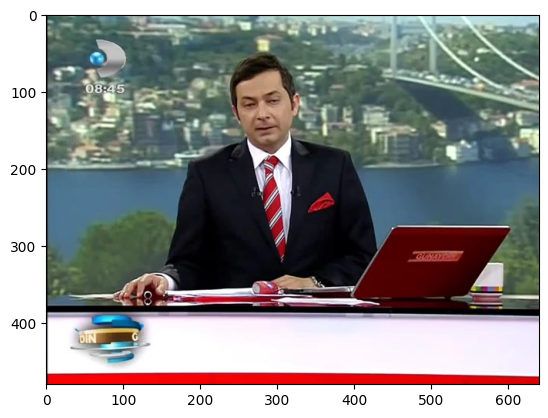

In [ ]:
import matplotlib.pyplot as plt
import cv2

img = cv2.imread("dataset/real/" + os.listdir("dataset/real")[0])
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.show()

In [ ]:
import torch.nn as nn

class SimpleCNN(nn.Module):
  def __init__(self):
    super(SimpleCNN).__init__()

    self.conv = nn.Sequential(
        nn.Conv2d(3, 16, 3),
        nn.ReLU(),
        nn.MaxPool2d(2),

        nn.Conv2d(16, 32, 3),
        nn.ReLU(),
        nn.MaxPool2d(2)
    )

    self.fc = nn.Sequential(
        nn.Linear(32 * 30 * 30, 128),
        nn.ReLU(),
        nn.Linear(128, 2)
    )

  def forward(self, x):
    x = self.conv(x)
    x = x.view(x.size(0), -1)
    x = self.fc(x)
    return x
